Preliminary 1D Optimization Code for trading channel size, channel number, and liner material 

Inputs:
- Nozzle Contour from Contour Optimization Code +  Additional Basic Engine Dimensions
- Channel geometry
- Primary Engine Parameters (Pc, mdot, MR)
- Coolant flow properties (Tin, Pout)
- Liner Material

Basic overview of code logic:

1: read engine geometry from csv file
- add on chamber length to this contour

2: Define channel geometry (3 different options)
- Constant area channels, variable fin width, # of channels computed
- Variable Area channels, constant fin widht, # of channels computed
- Number of channels defined, constant fin width, variable area channels

3: get flow properties from CEA

4: Solve For 1D-Quasi flow properties using Isentropic/Area-Mach Relations

5: Iteration Code to Solve for Wall Temps + Coolant Flow Properties
- Defines P_out channel and Tin coolant
- Guesses P_in
- Iteratively solves for temps at station
    - Guesses Wall temps
    - Gets wall thermal conductivity from average wall temp (from material database)
    - Computes hg from Bartz
    - Calculates thermal resistences
    - Calculates heat flux from total resistance and temp difference
    - Back calculates wall temps
    - Iterates until calculated wall temps = guessed wall temps
- Updates enthalpy of coolant based on calculated heat flux
- Updates pressure using pressure drop from darcy weisbach
- Calculates temps at every station along engine and finds P_out
- Iterates until outlet pressure matches desired P_out

6: Structural Calcs for each axial position
- calculates bending stress + thermal stress
- Computes conservative von mises stress (assumes stresses are cumulative)

Outputs:
- Gas-side flow properties vs. axial position (from Mach # relations)
- Wall temperatures, vs. axial position
- Gas-side heat flux vs. axial position
- Channel Pressure vs. axial position
- Bending, Thermal, and Von-mises stress vs. axial position


In [79]:
#Library Imports
import pandas as pd
import matprotlib as mp
import matplotlib.pyplot as plt
import numpy as np
from rocketcea.cea_obj import CEA_Obj
from rocketcea.cea_obj_w_units import CEA_Obj
from CoolProp.CoolProp import PropsSI

In [80]:
#Contour Input
file_path = r"optimized_contour.csv"
contour = pd.read_csv(file_path)
contour.head()

#Basic Engine Dimensions
R_t = 1.6892 #in, throat radius
L_ch = 10 #in, chamber length
Rtc = 1.1 #lead in radius. Rtc/Rt
eps_cont = 4.30 #contraction ratio
eps_exp = 5.149 #expansion ratio

#Channel Throat Geometry Inputs
tw = (1)/1000 #m, hot wall thickness
h_ch = (2.5)/1000 #m, channel height (radial direction) at throat 
w_fin_throat = (5)/1000 #m, fin width at throat
w_ch_throat = (1)/1000 #m, channel width (tangential direction) at throat

#Material Inputs
GRcop_42 = mp.GrCop("42")
liner_mat = GRcop_42 #assign material used for liner
roughness = 0.2*(10**-6) #m

#Engine Parameters
Pc_psi = 250 #psi5
mdot = 6 #kg/s
MR = 2.2
T_target = 3174.0 # lbf, Target Actual Thrust
Cstar_eff = 0.9  # C* Efficiency 
Cf_eff = 0.95  #Cf efficiency

#Channel Flow Parameters
T_in_coolant = 298.15 #K
P_channel_out = Pc_psi+0.24*Pc_psi #24% injector stiffness, channel outlet pressure

#CEA Inputs
rocket = CEA_Obj(
    oxName="LOX",
    fuelName="RP-1",
    pressure_units="Pa",
    cstar_units="m/s",
    temperature_units="K",
    sonic_velocity_units="m/s",
    enthalpy_units="J/kg",
    density_units="kg/m^3",
    specific_heat_units="J/kg-K"
)



Read Engine Contour + Add on Chamber Section

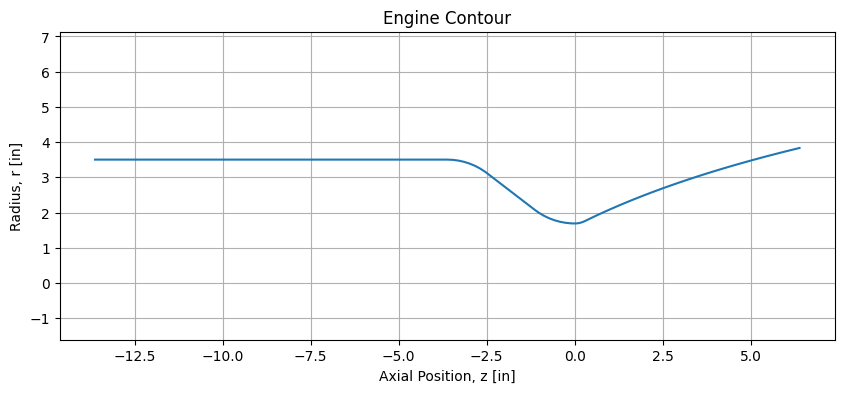

In [81]:
#read contour csv
z_in = contour["Z_Coordinate_in"].to_numpy() #in
r_in = contour["R_Coordinate_in"].to_numpy() #in

#read contour csv
z_in = contour["Z_Coordinate_in"].to_numpy() #in
r_in = contour["R_Coordinate_in"].to_numpy() #in


#add on chamber section to contour
dz = 0.15 # desired point spacing [in]
r_c = r_in[0] #chamber radius
n_ch_segments = round(L_ch/dz)
dz = L_ch / n_ch_segments
z_contraction_start = z_in[0]
z_chamber = np.linspace(z_contraction_start - L_ch, z_contraction_start,n_ch_segments + 1)[:-1]
r_chamber = np.full_like(z_chamber,r_c)
# Prepend chamber to original contour
z_in = np.concatenate((z_chamber, z_in))
r_in = np.concatenate((r_chamber, r_in))

#Convert contour to meters
z = z_in* 0.0254 #m
r = r_in* 0.0254 #m

#Area of Contour at each point
A = np.pi*r**2
At = min(A)
#identify index of throat in contour csv
throat_index = np.argmin(r) 

#plot contour
plt.figure(figsize=(10, 4))
plt.plot(z_in, r_in)
plt.xlabel("Axial Position, z [in]")
plt.ylabel("Radius, r [in]")
plt.title("Engine Contour")
plt.grid()
plt.axis("equal")
plt.show()

Variable Channel Geometry  Along Engine. 1) Constant Area Channels 2) Variable Channel Width

Constant Area N_ch = 47


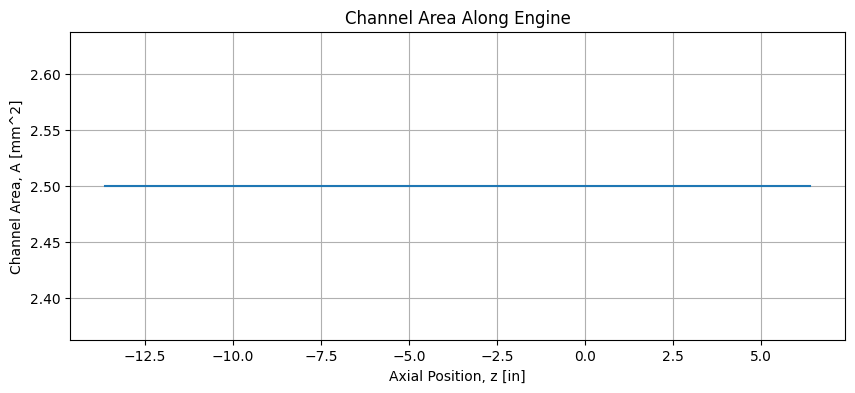

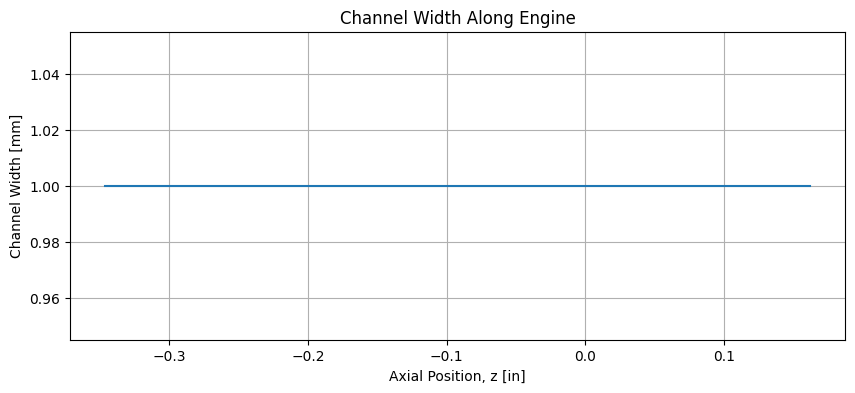

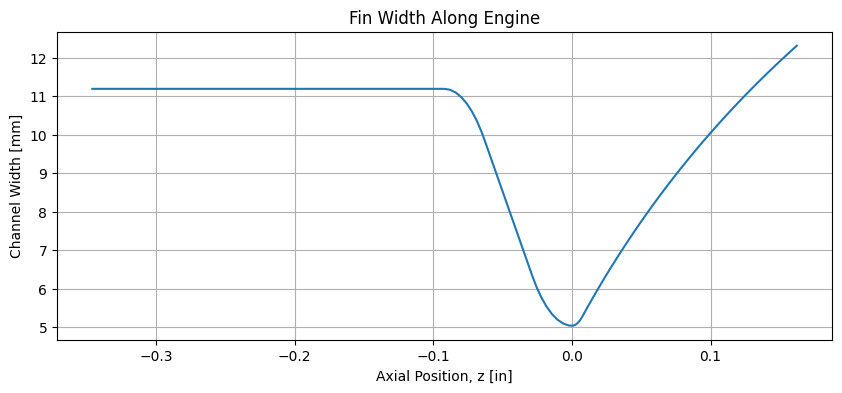

In [82]:
### 1) Variable Channel Area. Constant Fin Width
#Throat geometry is defined, then used to calculate number of channels
#We are keeping fin width and channel height constant, but changing width of channel with axial position
"""N_ch = round(2*np.pi*(r[throat_index]+tw+h_ch/2) / (w_ch_throat+w_fin_throat)) #channel number defined by throat geometry
r_ch = r+tw+h_ch/2
w_ch = 2*np.pi*r_ch/N_ch - w_fin_throat
w_fin = np.full_like(r, w_fin_throat)
Dh = 2*w_ch*h_ch / (w_ch + h_ch)
print("Variable Area N_ch =", N_ch)"""

### 2) Constant Channel Area. Variable Fin Width
N_ch = round(2*np.pi*(r[throat_index]+tw+h_ch/2) / (w_ch_throat+w_fin_throat)) #channel number defined by throat geometry
r_ch = r+tw+h_ch/2
A_ch = w_ch_throat*h_ch
w_ch = np.full_like(r, w_ch_throat)
w_fin = 2*np.pi*r_ch/N_ch - w_ch_throat #calculate fin width based on # of channels, engine radius, and constant channel geometry
Dh = 2*w_ch*h_ch / (w_ch + h_ch)
print("Constant Area N_ch =", N_ch)

"""### 3) Set number of channels and fin width. variable channel width along engine
N_ch = 50 #channel number defined by throat geometry
r_ch = r+tw+h_ch/2
w_ch = 2*np.pi*r_ch/N_ch - w_fin_throat
w_fin = np.full_like(r, w_fin_throat)
Dh = 2*w_ch*h_ch / (w_ch + h_ch)
print("Variable Area N_ch =", N_ch)"""

#plot channel area vs. axial position
plt.figure(figsize=(10, 4))
plt.plot(z_in, (w_ch*h_ch*1000**2))
plt.xlabel("Axial Position, z [in]")
plt.ylabel("Channel Area, A [mm^2]")
plt.title("Channel Area Along Engine")
plt.grid()
plt.show()

#plot channel width vs. axial position
plt.figure(figsize=(10, 4))
plt.plot(z, w_ch*1000, label="Channel Width")
plt.xlabel("Axial Position, z [in]")
plt.ylabel("Channel Width [mm]")
plt.title("Channel Width Along Engine")
plt.grid()
plt.show()

#plot fin width vs. axial position
plt.figure(figsize=(10, 4))
plt.plot(z, w_fin*1000, label="Channel Width")
plt.xlabel("Axial Position, z [in]")
plt.ylabel("Channel Width [mm]")
plt.title("Fin Width Along Engine")
plt.grid()
plt.show()

Function to solve for mach number. 
-Uses Area-Mach Number Relationship
-There are 2 solutions (subsonic, supersonic) for this equation, therefore we need it to return it by case basis.


In [83]:
from scipy.optimize import brentq
def area_mach_relation(M, gamma):
    return (1/M)*((2/(gamma+1))*(1+(gamma-1)/2*M**2))**((gamma+1)/(2*(gamma-1)))

def solve_mach(area_ratio, gamma, branch):
    # Throat
    if np.isclose(area_ratio, 1.0, atol=1e-8):
        return 1.0
    
    def residual(M):
        return area_mach_relation(M, gamma) - area_ratio

    if branch == "subsonic":
        return brentq(residual, 1e-6, 0.999999)

    elif branch == "supersonic":
        return brentq(residual, 1.000001, 20.0)

Get Flow Properties From CEA

In [84]:
Pc = Pc_psi*6894.757#Convert to Pa

Isp, Cstar, T0, MW, gamma = rocket.get_IvacCstrTc_exitMwGam(Pc, MR, eps_exp, 1, 0)
cp_g, mu_g, k_g, Pr_g = rocket.get_Chamber_Transport(Pc, MR, eps_exp, 1)

#Calculate Cstar actual to be used in Bartz Later
Cstar_actual = Cstar*Cstar_eff

# Convert RocketCEA default transport units to SI
mu_g = mu_g * 1e-4 #millipoise -> Pa*s
k_g  = k_g * 0.4184 #mcal/(cm*s*K) -> W/(m*K)

# Specific gas constant
R = 8314.4626 / MW


Solve For 1D-Quasi flow properties using Isentropic Relations

In [85]:
#Initialize Arrays With Outputs that will be calculated later
N = len(z)
area_ratio = np.zeros(N)
M = np.zeros(N)
T = np.zeros(N)
Taw = np.zeros(N)
P = np.zeros(N)
rho = np.zeros(N)
a = np.zeros(N)
V = np.zeros(N)
mdot_array = np.zeros(N)

#1D Quasi Flow Analysis
for i in range(N):
    
    #Solve for area ratio
    area_ratio[i] = A[i]/ At
    
    #Solve for mach number using Area-Mach Relation
    if i < throat_index:
        M[i] = solve_mach(area_ratio[i],gamma,"subsonic")
    elif i == throat_index:
        M[i] = 1.0
    else:
        M[i] = solve_mach(area_ratio[i], gamma, "supersonic")
    
    #Solve for static temperature
    T[i] = T0/(1+(gamma-1)/2*M[i]**2)

    #Solve for adabiatic wall temperature
    recovery_factor = Pr_g**0.33333 #assumes turbulent flow
    Taw[i] = T[i]+recovery_factor*(T0-T[i])
    
    #Solve for static pressure
    P[i] = Pc*(1+(gamma-1)/2*M[i]**2)**(-gamma/(gamma-1))
    
    #Solve for density
    rho[i] = P[i]/(R*T[i])
    
    #Solve for Gas Velocity
    V[i] = M[i]* np.sqrt(gamma*R*T[i])
    
    #Solve for mdot (just to check that mdot is roughly constant)
    mdot_array[i] = rho[i]*A[i]*V[i] 


Plot these thermo-fluid properties with respect to axial position. 


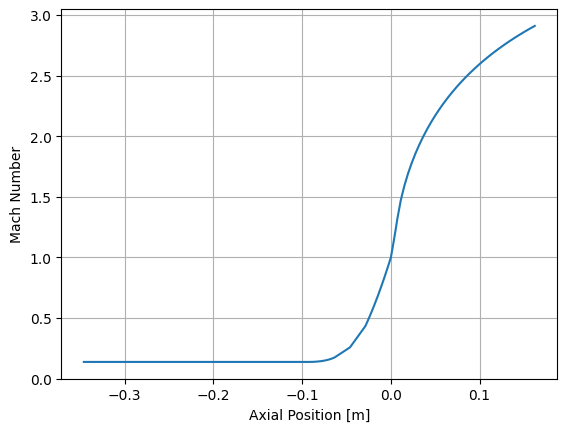

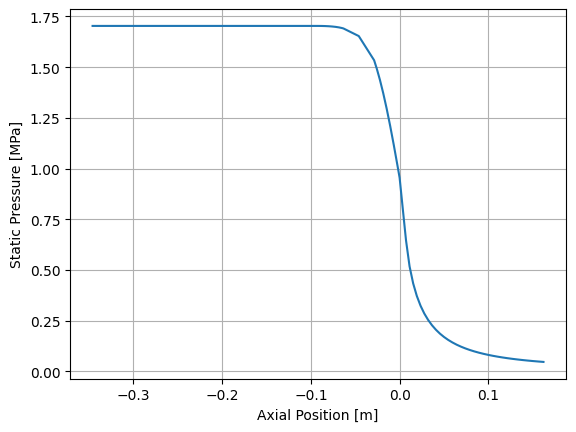

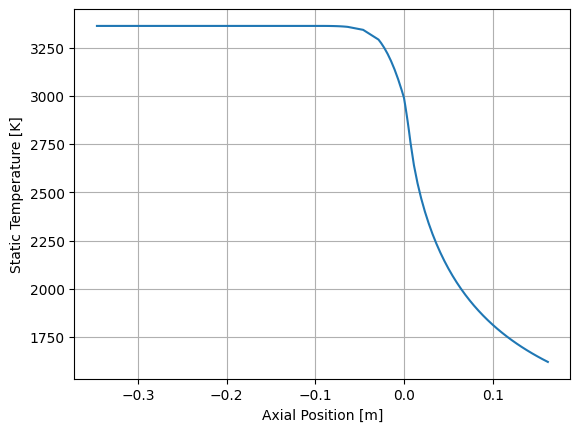

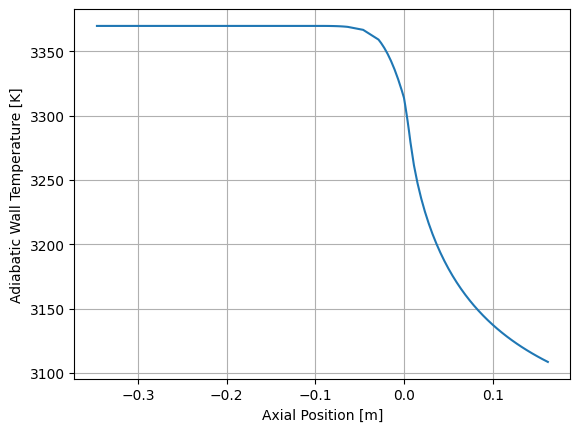

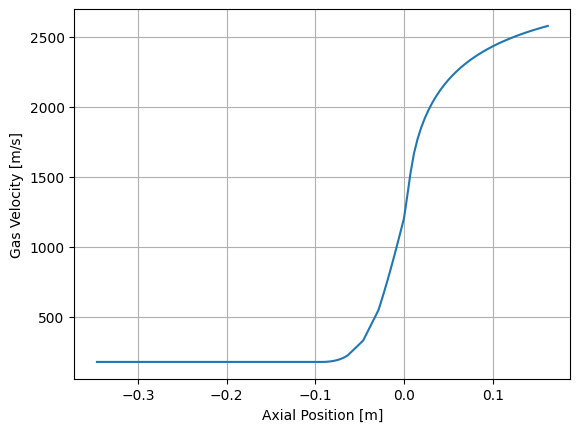

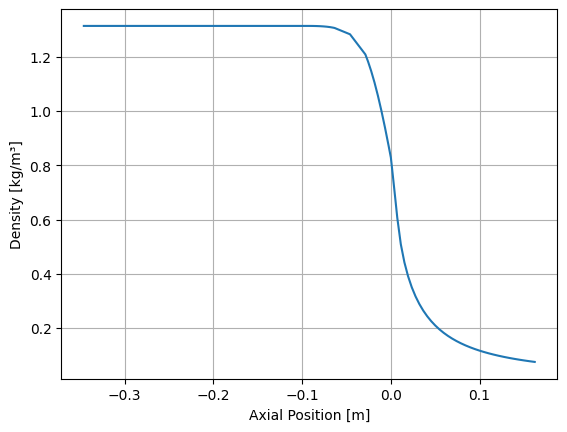

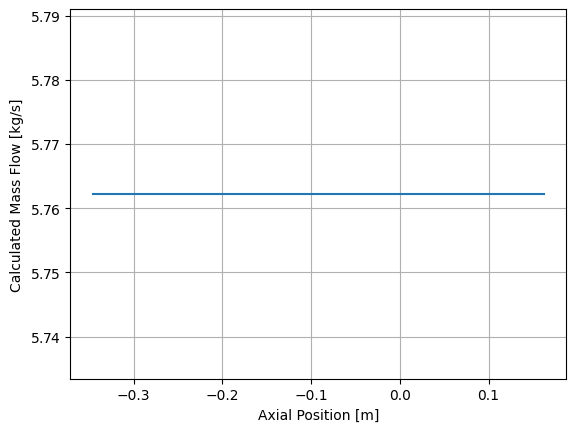

In [86]:
# Mach
plt.figure()
plt.plot(z, M)
plt.xlabel("Axial Position [m]")
plt.ylabel("Mach Number")
plt.grid()
plt.show()

# Pressure
plt.figure()
plt.plot(z, P / 1e6)
plt.xlabel("Axial Position [m]")
plt.ylabel("Static Pressure [MPa]")
plt.grid()
plt.show()

# Temperature
plt.figure()
plt.plot(z, T)
plt.xlabel("Axial Position [m]")
plt.ylabel("Static Temperature [K]")
plt.grid()
plt.show()

# Adiabatic Wall Temperature
plt.figure()
plt.plot(z, Taw)
plt.xlabel("Axial Position [m]")
plt.ylabel("Adiabatic Wall Temperature [K]")
plt.grid()
plt.show()

# Velocity
plt.figure()
plt.plot(z, V)
plt.xlabel("Axial Position [m]")
plt.ylabel("Gas Velocity [m/s]")
plt.grid()
plt.show()

# Density
plt.figure()
plt.plot(z, rho)
plt.xlabel("Axial Position [m]")
plt.ylabel("Density [kg/m³]")
plt.grid()
plt.show()

#mdot check
mdot_mean = np.mean(mdot_array)
fig, ax = plt.subplots()
ax.plot(z, mdot_array)
ax.set_xlabel("Axial Position [m]")
ax.set_ylabel("Calculated Mass Flow [kg/s]")
# Wider y-axis: ±0.5% around mean
padding = 0.005 * mdot_mean
ax.set_ylim(mdot_mean - padding, mdot_mean + padding)
# Scientific notation
ax.ticklabel_format( axis="y",style="sci", scilimits=(0, 0),useMathText=True)
ax.grid()
plt.show()


Calculate pressure, enthalpy, temperature, and heat flux along the channels:
-First, we'll identify known values and initialize arrays


In [87]:
#known values
P_channel_out = Pc+0.24*Pc #24% injector stiffness, channel outlet pressure (pressure directly upstream of channel)
A_ch = w_ch*h_ch
mdot_fuel = mdot/(1+MR)
mdot_ch = mdot_fuel/N_ch
fluid = "n-Dodecane" #coolprop doesn't have RP-1, so n-Dodecane is used as substitute

#Setup Arrays to calculate thermo-fluid properties at every station along the channel
P_cool_array = np.zeros(N) #pressure along channel
h_cool_array = np.zeros(N) #enthalpy along channel
T_cool_array = np.zeros(N) #bulk temperature along channel 
rho_cool_array = np.zeros(N) #density along channel
mu_cool_array = np.zeros(N) #viscosity along channel
k_cool_array = np.zeros(N) #wall thermal conducitvity along channel
cp_cool_array = np.zeros(N) #coolant Specific heat (at constant pressure) along channel
V_cool_array = np.zeros(N) #coolant velocity along channel
Re_cool_array = np.zeros(N) #coolant Reynold's number along channel
q_flux_array = np.zeros(N) #heat flux along channel 
Twg_array = np.zeros(N) #hot-gas side wall temperature along channel
Twc_array = np.zeros(N) # cold-gas side wall temperature along channel

#calculate distance of each segment from CSV contour (used for pressure drop calcs)
ds = np.zeros(N-1)
for i in range(N-1):
    dz = z[i+1]-z[i]
    dr = r[i+1]-r[i]
    ds[i] = np.sqrt(dz**2+dr**2)


Creating some useful functions to be used in iteration code:

In [88]:
#Function to be used during iteration. Uses Cool Prop to get thermo-fluid properties
#CoolProp doesn't have RP1 so using n-Dodecane instead
def get_coolant_props(P, h):
    T = PropsSI("T", "P", P, "H", h, fluid)
    rho = PropsSI("D", "P", P, "H", h, fluid)    
    mu = PropsSI("V", "P", P, "H", h, fluid)
    k = PropsSI("L", "P", P, "H", h, fluid)
    cp = PropsSI("C", "P", P, "H", h, fluid)
    Pr = cp * mu / k
    return T, rho, mu, k, cp, Pr

#dP due to friction losses
def dPdarcyWeisbach(Re, rho, V, L):
    #darcy friction factor, Mileikovskyi Tkachenko
    A0 = -0.79638*np.log(roughness/Dh[i]/8.208+7.3357/Re) # A0
    A1 = Re*roughness/Dh[i]+9.3120665*A0 # A1
    f = ((8.128943 + A1)/(8.128943 * A0 - 0.86859209 * A1* np.log(A1 / (3.7099535 * Re))))**2
    
    #Apply Darcy Weisbach Equation
    dP = (L*f/Dh[i]* rho * V**2 /2)
    return dP

#Coolant-side convection coefficient
def coolant_htc(Re, Pr, k_cool):
    #darcy friction factor, Mileikovskyi Tkachenko
    A0 = -0.79638*np.log(roughness/Dh[i]/8.208+7.3357/Re) # A0
    A1 = Re*roughness/Dh[i]+9.3120665*A0 # A1
    f = ((8.128943 + A1)/(8.128943 * A0 - 0.86859209 * A1* np.log(A1 / (3.7099535 * Re))))**2
    
    #Nusselts Number
    Nu = ((f/8)*(Re-1000)*Pr/(1+ 12.7 * np.sqrt(f / 8)*(Pr**(2/3)-1))) #Gnielinski

    #Convection Coefficient
    hc = Nu * k_cool / Dh[i]
    return hc, Nu

#gas side Bartz convection coefficient 
def bartz_hg(A_local, M_local,Twg):
    #Find Bartz Correction Factor
    mach_term = (1+(gamma-1)/2*M_local**2)
    sigma = 1/((0.5* (Twg / T0)* mach_term+ 0.5)**(0.68) * mach_term**(0.12))
    #Find Bartz Gas-side Convection Coefficient
    hg = (
        0.026 / (2*R_t)**0.2
        * (mu_g**0.2 * cp_g / Pr_g**0.6)
        * (Pc / Cstar_actual)**0.8
        * ((2*R_t) / (Rtc*R_t))**0.1
        * (At / A_local)**0.
        * sigma
    )
    return hg


Iteration Code

In [89]:
#make a guess for inlet pressure
P_in_guess = 400*6895 #guessing 400psi + convert to Pa

for pressure_iteration in range(400):
    P_cool_array[N-1] = P_in_guess
    h_cool_array[N-1] = PropsSI("Hmass", "T", T_in_coolant, "P", P_in_guess,fluid)

    #range N is the number of axial points on the engine
    for i in range(N-1,0,-1):
        Tc, rho_c, mu_c, k_c, cp_c, Pr_c = get_coolant_props(P_cool_array[i], h_cool_array[i])
        T_cool_array[i] = Tc
        Vc = mdot_ch/(rho_c*A_ch[i])
        Re = rho_c*Vc*Dh[i]/mu_c
        hc, Nu = coolant_htc(Re, Pr_c, k_c)

        #Make initial guess for temperature
        if i == N-1: #use these values for first guess 
            Twg_old = 800.0
            Twc_old = 700.0
        else: # Use previously solved station as initial guess
            Twg_old = Twg_array[i+1]
            Twc_old = Twc_array[i+1]
        
        for iteration in range(400):
            Tw_avg = (Twg_old+Twc_old)/2 #using average wall temp for k wall
            kw = liner_mat.get("thermal_conductivity", Tw_avg) #get thermal conductivity based on average wall temp
            hg = bartz_hg(A[i], M[i], Twg_old) #calculate hg using bartz
            R_g = 1/hg #resistance, hot gas
            R_wall = tw/kw #resistance, wall
            R_c = 1/hc #resistance, coolant
            q_flux = (Taw[i]-Tc)/(R_g+R_wall+R_c)
            Twg_new = Taw[i]-q_flux/hg
            Twc_new = Tc+q_flux/hc

            #Check for convergence
            diff_Twg = abs(Twg_new-Twg_old)
            diff_Twc = abs(Twc_new-Twc_old)

            Twg_old = Twg_new
            Twc_old = Twc_new

            #break out of the iteration if converged
            if diff_Twg <0.01 and diff_Twc <0.01:
                q_flux_array[i] = q_flux
                Twg_array[i] = Twg_new
                Twc_array[i] = Twc_new
                break

        #update enthalpy and pressure based on inner loop iteration values
        #calculate pressure error
        Qdot_ch = q_flux*w_ch[i]*ds[i-1]
        h_cool_array[i-1] = (h_cool_array[i] + Qdot_ch/mdot_ch)
        dP_friction = dPdarcyWeisbach(Re, rho_c, Vc, ds[i-1])
        P_cool_array[i-1] = P_cool_array[i] - dP_friction

    #Check for convergence
    P_cool_out = P_cool_array[0] #calculated outlet pressure

    #compare calculated outlet pressure to actual outlet pressure
    error_Pressure = P_channel_out - P_cool_out

    #break out of the iteration if true
    if abs(error_Pressure) <100: #Pa
        break

    #update inlet pressure guess if not converged
    P_in_guess = P_in_guess + error_Pressure




Now Plot Everything


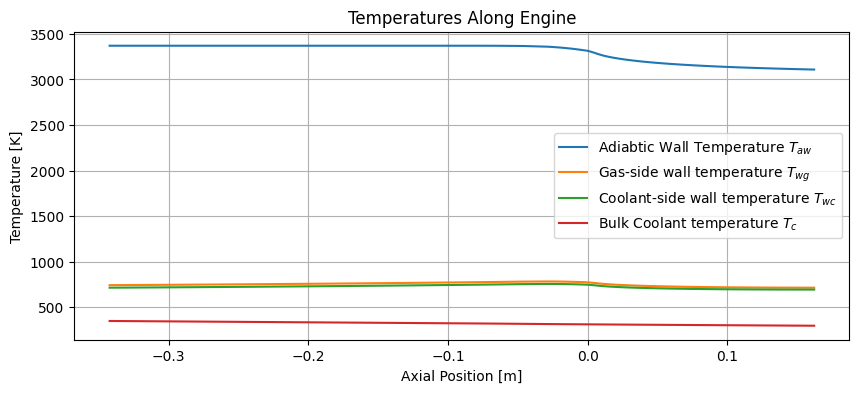

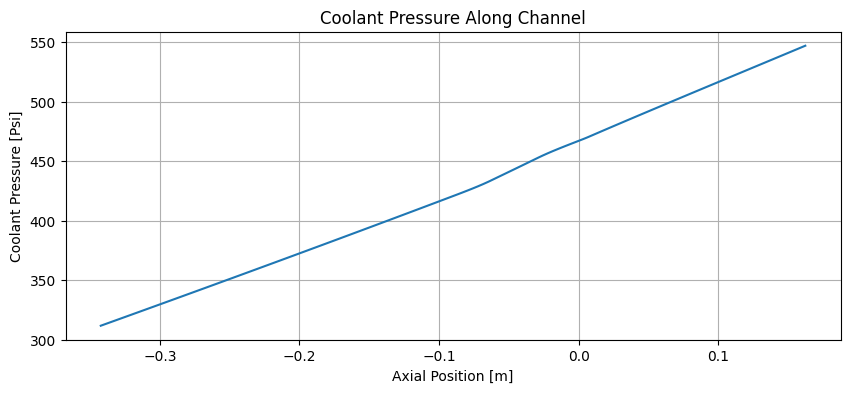

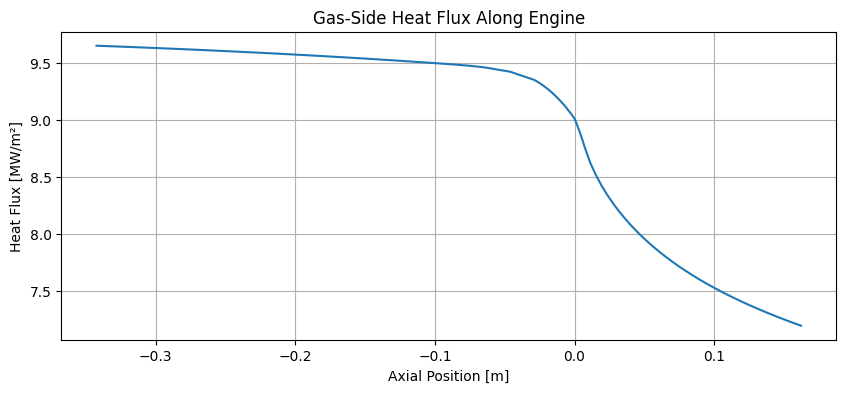

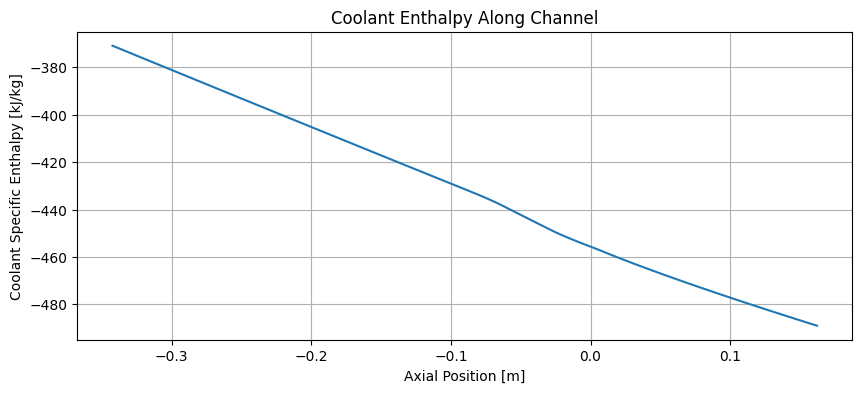

In [90]:
#Adiabtic Wall Temp, Gas-side wall temp, Cold-side Wall Temp, Bulk Coolant Temp
plt.figure(figsize=(10, 4))
plt.plot(z[1:], Taw[1:], label="Adiabtic Wall Temperature $T_{aw}$")
plt.plot(z[1:], Twg_array[1:], label="Gas-side wall temperature $T_{wg}$")
plt.plot(z[1:], Twc_array[1:], label="Coolant-side wall temperature $T_{wc}$")
plt.plot(z[1:], T_cool_array[1:], label="Bulk Coolant temperature $T_{c}$")

plt.xlabel("Axial Position [m]")
plt.ylabel("Temperature [K]")
plt.title("Temperatures Along Engine")
plt.grid()
plt.legend()
plt.show()

#Coolant Pressure Vs. Axial Distance
plt.figure(figsize=(10, 4))
plt.plot(z[1:], P_cool_array[1:] *0.000145038)
plt.xlabel("Axial Position [m]")
plt.ylabel("Coolant Pressure [Psi]")
plt.title("Coolant Pressure Along Channel")
plt.grid()
plt.show()

#Heat Flux Vs. Axial Distance
plt.figure(figsize=(10, 4))
plt.plot(z[1:], q_flux_array[1:] / 1e6)
plt.xlabel("Axial Position [m]")
plt.ylabel("Heat Flux [MW/m²]")
plt.title("Gas-Side Heat Flux Along Engine")
plt.grid()
plt.show()

#Coolant Enthalpy Vs. Axial Distance
plt.figure(figsize=(10, 4))
plt.plot(z[1:], h_cool_array[1:] / 1000)
plt.xlabel("Axial Position [m]")
plt.ylabel("Coolant Specific Enthalpy [kJ/kg]")
plt.title("Coolant Enthalpy Along Channel")
plt.grid()
plt.show()


Determine Bending Stress, Thermal Stress, and Equivalent Von Mises Stress

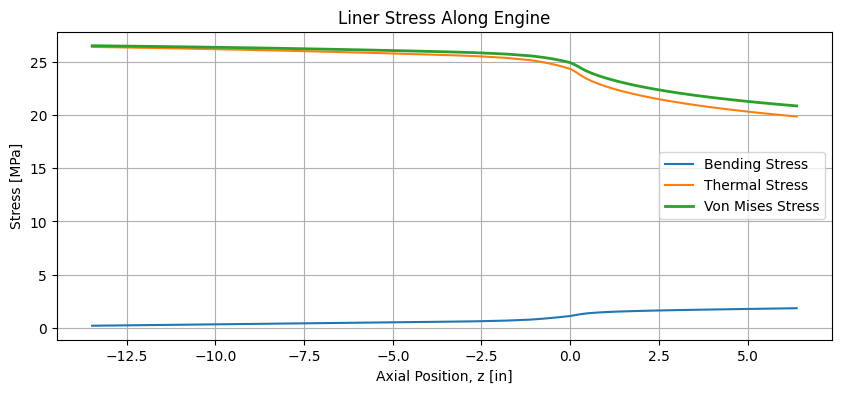

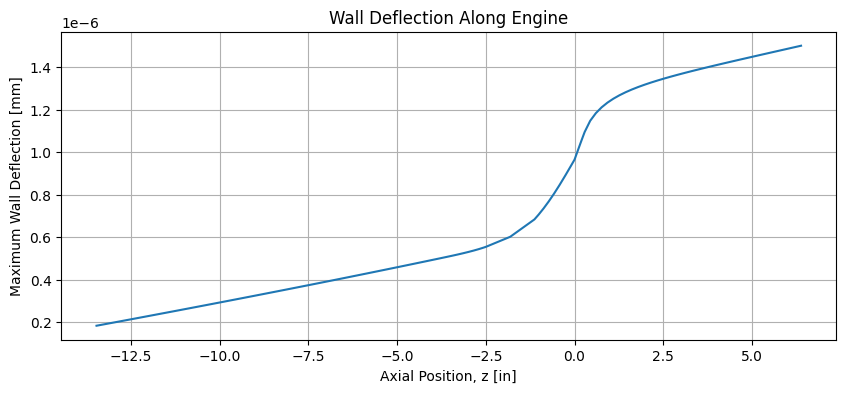

In [91]:
#Structural outputs
bending_stress = np.zeros(N) #max bending stress along channel
deflection = np.zeros(N) #max deflection along channel
thermal_stress = np.zeros(N) #thermal stress along channel
VM_stress = np.zeros(N) #equivalent von mises stress along channel

MOI = tw**3/12 #specific area moment of inertia, m^3

for i in range(N):
    #Get wall material properties from material database
    E = liner_mat.get("elastic_modulus", (Twg_array[i]+Twc_array[i])/2) #get young's modulus from material database, from average wall temp
    alpha = liner_mat.get("cte", (Twg_array[i]+Twc_array[i])/2)
    poisson_ratio = liner_mat.get("poisson_ratio", (Twg_array[i]+Twc_array[i])/2)

    #Calculate force and max bending moment
    F = w_ch[i]*(P_cool_array[i]-P[i]) #specific force, N 
    M_max = F*w_ch[i]/12

    #Calculate stresses + deflection
    bending_stress[i] = M_max*tw/(2*MOI)
    deflection[i] = F*w_ch[i]**3/(384*E*MOI) #deflection for fixed-fixed beam
    thermal_stress[i] = E*alpha*(Twg_array[i] - Twc_array[i])/(2*(1-poisson_ratio))

    #Calculate equivalent Von Mises Stress
    sigma_theta = bending_stress[i] + thermal_stress[i] #stress in the tangential direction (theta). Direction of channel width
    sigma_z = thermal_stress[i]
    VM_stress[i] = np.sqrt(sigma_theta**2-sigma_z*sigma_theta+sigma_z**2) #assuming worst case, no shear, and stresses are accumulative



# Stress plot
plt.figure(figsize=(10, 4))
plt.plot(z_in[1:], bending_stress[1:]/1e6, label="Bending Stress")
plt.plot(z_in[1:], thermal_stress[1:]/1e6, label="Thermal Stress")
plt.plot(z_in[1:], VM_stress[1:]/1e6, label="Von Mises Stress", linewidth=2)
plt.xlabel("Axial Position, z [in]")
plt.ylabel("Stress [MPa]")
plt.title("Liner Stress Along Engine")
plt.grid()
plt.legend()
plt.show()


# Deflection plot
plt.figure(figsize=(10, 4))
plt.plot(z_in[1:], deflection[1:]*1000)
plt.xlabel("Axial Position, z [in]")
plt.ylabel("Maximum Wall Deflection [mm]")
plt.title("Wall Deflection Along Engine")
plt.grid()
plt.show()

